# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Google Playstore Dataset](https://www.kaggle.com/datasets/ashyou09/google-play-store-apps-2026-edition/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('google_playstore_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
0,Strike Plus,FAMILY,4.6,12460594,Varies with device,"500,000,000+",Free,0.00,Teen,Family,"January 15, 2026",Varies with device,8.0 and up,Yes,Yes
1,Tracker AI,EDUCATION,3.4,11487705,Varies with device,"500,000,000+",Free,0.00,Everyone,Education,"October 22, 2025",Varies with device,11.0 and up,Yes,Yes
2,Scanner,FAMILY,3.5,10503932,Varies with device,"500,000,000+",Paid,0.99,Everyone,Family,"November 08, 2024",Varies with device,10.0 and up,No,No
3,Connect 3D,ART_AND_DESIGN,4.7,4818860,221.6M,"100,000,000+",Free,0.00,Everyone,Art And Design,"October 07, 2025",6.8.21,10.0 and up,No,Yes
4,VPN,PRODUCTIVITY,3.5,3562800,122.9M,"100,000,000+",Free,0.00,Everyone,Productivity,"June 29, 2026",5.5.11,12.0 and up,Yes,Yes


## last Five row

In [4]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
11495,Epic Learn Plus,PRODUCTIVITY,NaN,0,74.3M,10+,Free,0.0,Everyone,Productivity,"August 16, 2024",8.8.45,11.0 and up,Yes,Yes
11496,Scanner Pro,PHOTOGRAPHY,NaN,0,34.8M,10+,Free,0.0,Everyone,Photography,"September 10, 2024",7.9.59,11.0 and up,Yes,Yes
11497,Dash 2023,WEATHER,NaN,0,34.4M,10+,Free,0.0,Everyone,Weather,"November 13, 2025",2.3.74,9.0 and up,Yes,Yes
11498,Pro Strike,BOOKS_AND_REFERENCE,NaN,0,81.1M,10+,Free,0.0,Everyone,Books And Reference,"October 30, 2025",2.7.72,12.0 and up,Yes,No
11499,Health,FINANCE,NaN,0,139.0M,10+,Free,0.0,Everyone,Finance,"December 01, 2025",15.15.37,10.0 and up,No,Yes


## Shape of our dataset

In [5]:
df.shape

(11500, 15)

## List out all columns

In [6]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'In-App Purchases', 'Ad Supported'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

App                  object
Category             object
Rating              float64
Reviews               int64
Size                 object
Installs             object
Type                 object
Price               float64
Content Rating       object
Genres               object
Last Updated         object
Current Ver          object
Android Ver          object
In-App Purchases     object
Ad Supported         object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               11500 non-null  object 
 1   Category          11500 non-null  object 
 2   Rating            6123 non-null   float64
 3   Reviews           11500 non-null  int64  
 4   Size              11500 non-null  object 
 5   Installs          11500 non-null  object 
 6   Type              11500 non-null  object 
 7   Price             11500 non-null  float64
 8   Content Rating    11500 non-null  object 
 9   Genres            11500 non-null  object 
 10  Last Updated      11500 non-null  object 
 11  Current Ver       11500 non-null  object 
 12  Android Ver       11500 non-null  object 
 13  In-App Purchases  11500 non-null  object 
 14  Ad Supported      11500 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 1.3+ MB


## Check Null Value

In [9]:
df.isnull().sum()

App                    0
Category               0
Rating              5377
Reviews                0
Size                   0
Installs               0
Type                   0
Price                  0
Content Rating         0
Genres                 0
Last Updated           0
Current Ver            0
Android Ver            0
In-App Purchases       0
Ad Supported           0
dtype: int64

## Drop Null Features

In [10]:
df.drop(columns=['Rating'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Reviews,Price
count,1.150000e+04,11500.000000
mean,8.550739e+03,0.217415
std,2.045769e+05,4.169775
min,0.000000e+00,0.000000
25%,2.000000e+00,0.000000
50%,5.000000e+00,0.000000
75%,4.500000e+01,0.000000
max,1.246059e+07,399.990000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

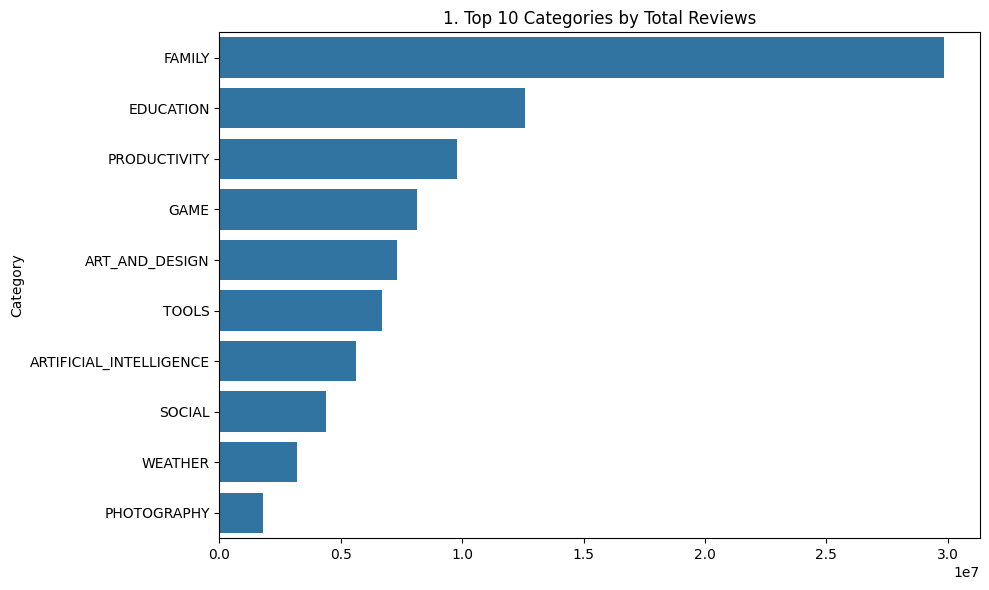

In [14]:
fig = plt.figure(figsize=(10,6))
category_reviews = df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=category_reviews.values, y=category_reviews.index)
plt.title(f'{plot_no}. Top 10 Categories by Total Reviews')
show_fig()
plot_no += 1

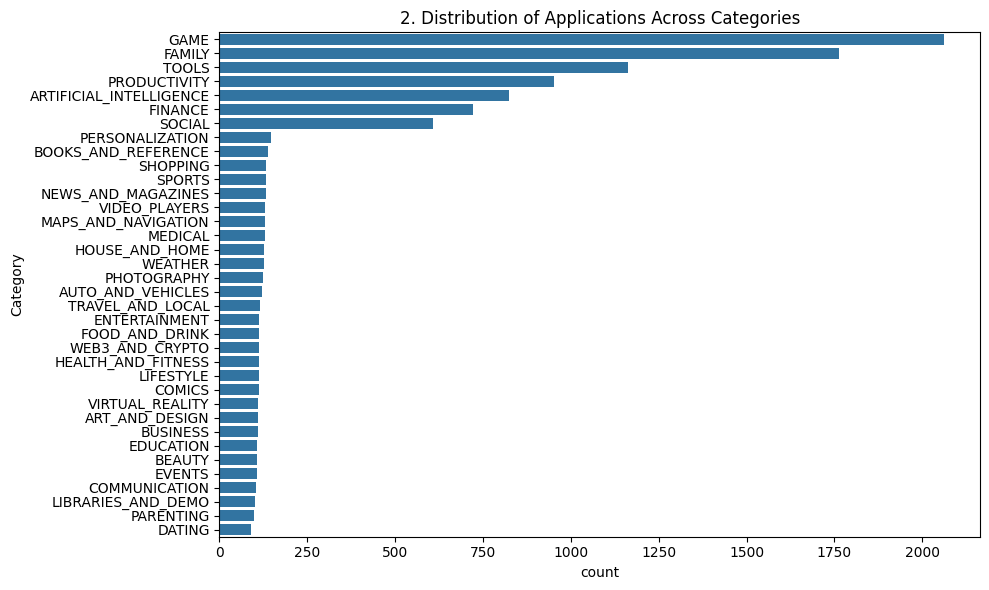

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Applications Across Categories')
show_fig()
plot_no += 1

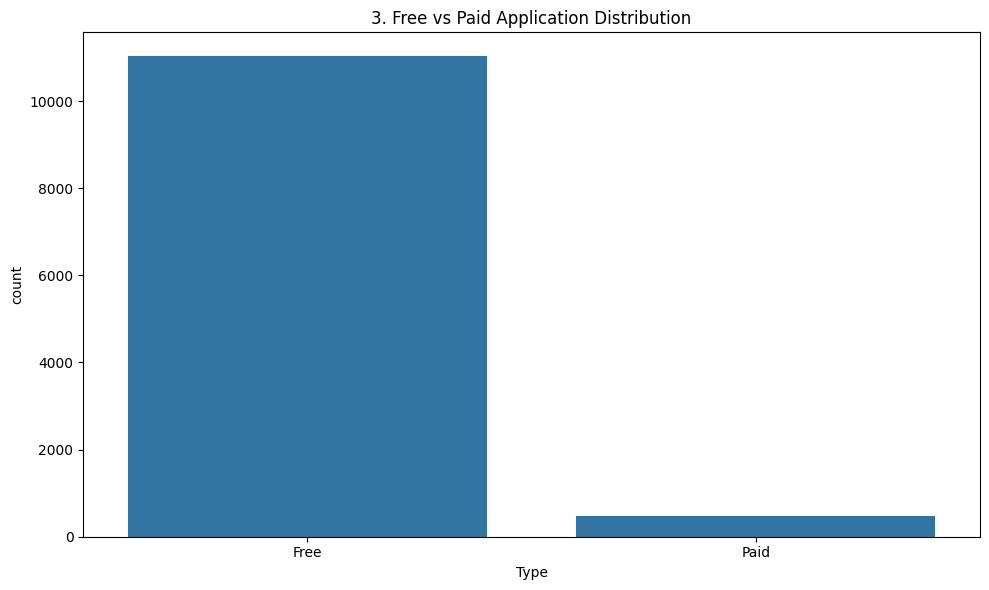

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Type', data=df)
plt.title(f'{plot_no}. Free vs Paid Application Distribution')
show_fig()
plot_no += 1

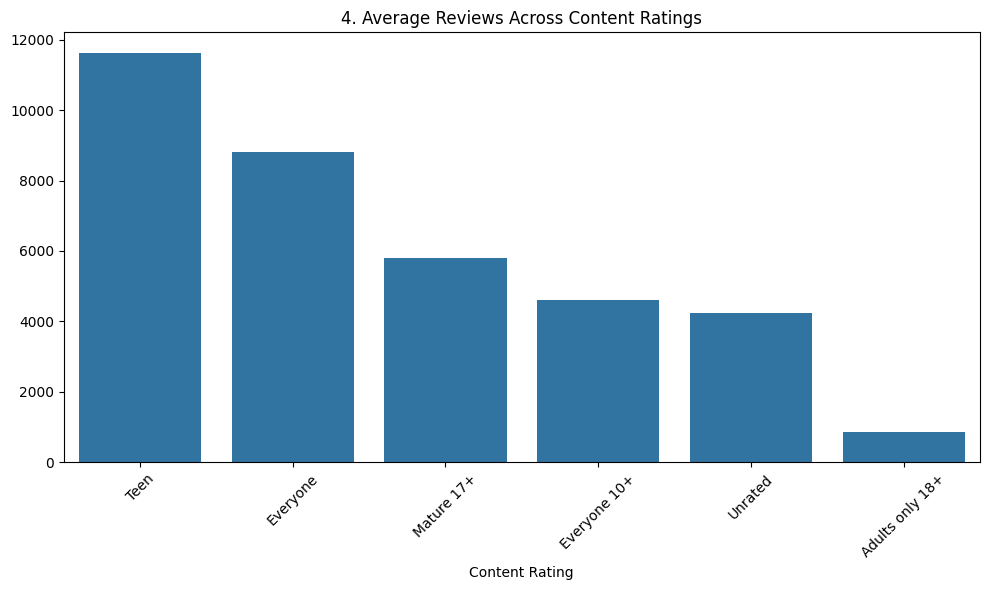

In [17]:
fig = plt.figure(figsize=(10,6))
content_reviews = df.groupby('Content Rating')['Reviews'].mean().sort_values(ascending=False)
sns.barplot(x=content_reviews.index, y=content_reviews.values)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Reviews Across Content Ratings')
show_fig()
plot_no += 1

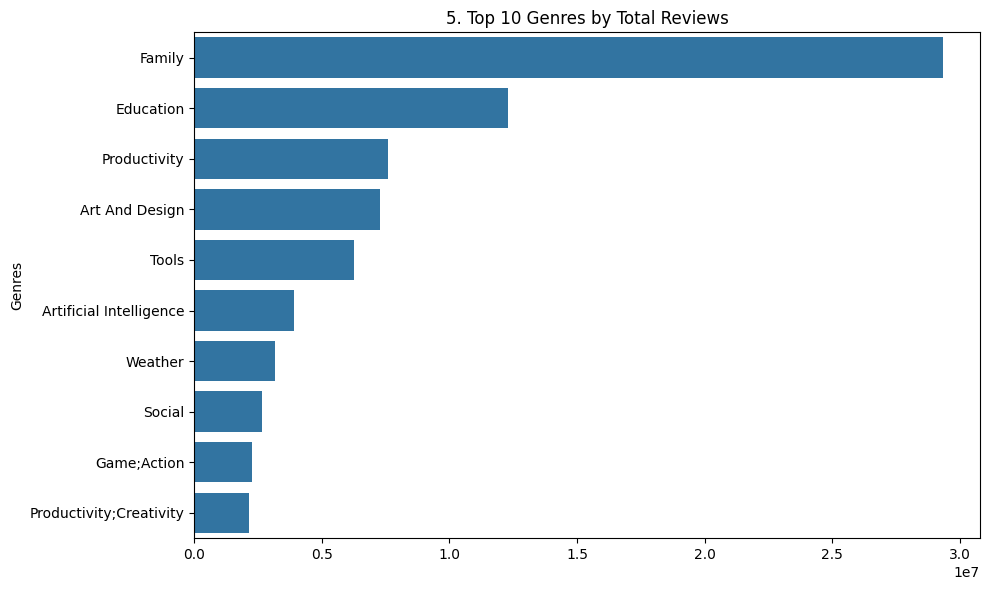

In [18]:
fig = plt.figure(figsize=(10,6))
genre_reviews = df.groupby('Genres')['Reviews'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=genre_reviews.values, y=genre_reviews.index)
plt.title(f'{plot_no}. Top 10 Genres by Total Reviews')
show_fig()
plot_no += 1

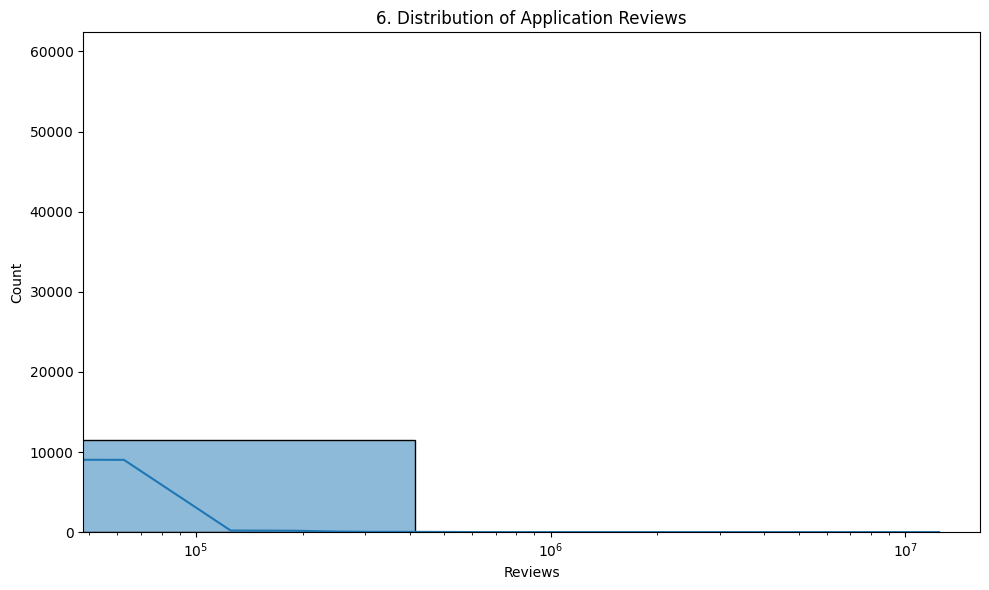

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Reviews'], bins=30, kde=True)
plt.xscale('log')
plt.title(f'{plot_no}. Distribution of Application Reviews')
show_fig()
plot_no += 1

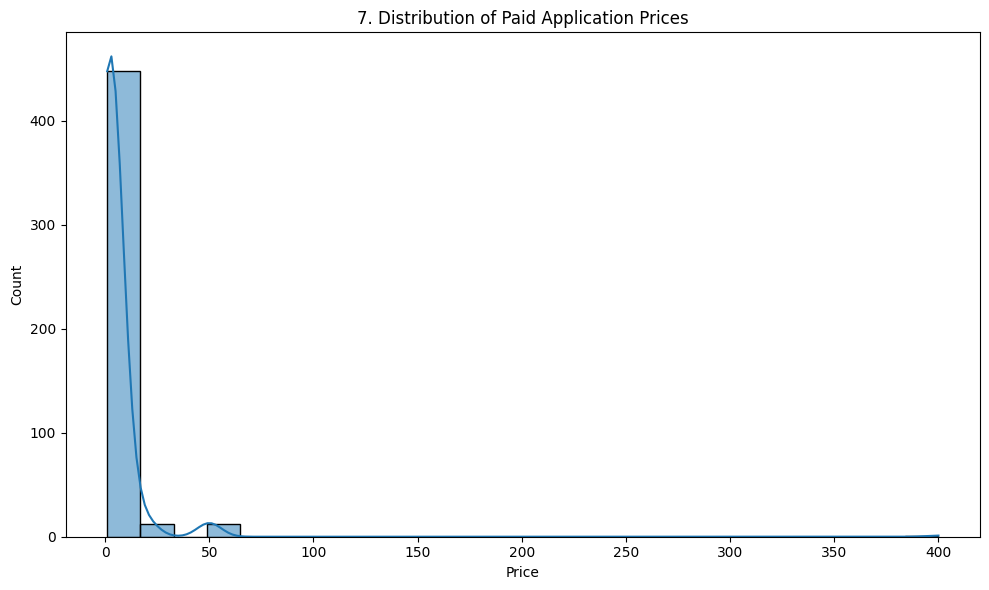

In [20]:
fig = plt.figure(figsize=(10,6))
price_df = df[df['Price'] > 0]
sns.histplot(price_df['Price'], bins=25, kde=True)
plt.title(f'{plot_no}. Distribution of Paid Application Prices')
show_fig()
plot_no += 1

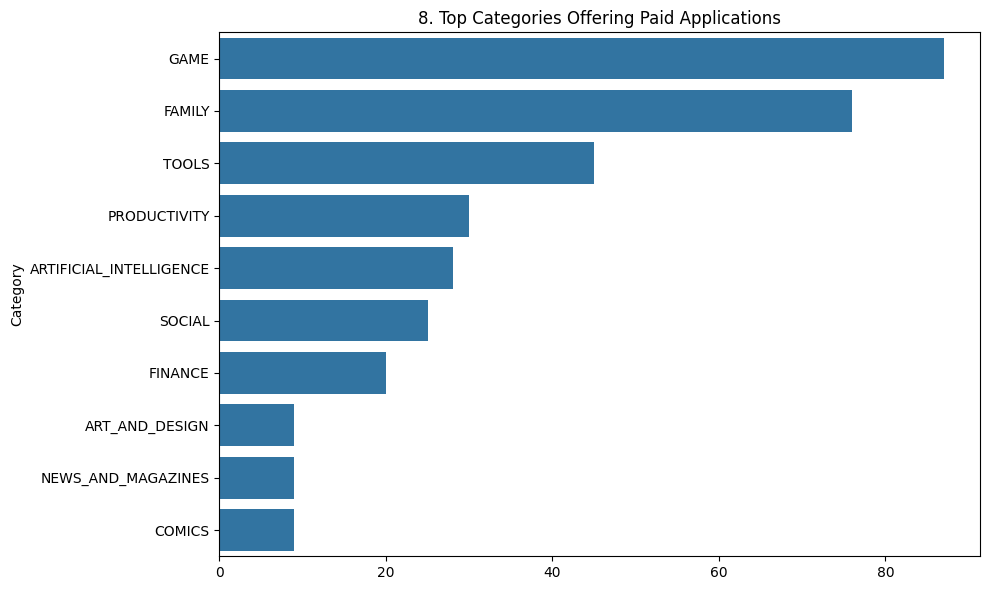

In [21]:
fig = plt.figure(figsize=(10,6))
paid_category = df[df['Type']=='Paid'].groupby('Category').size().sort_values(ascending=False).head(10)
sns.barplot(x=paid_category.values, y=paid_category.index)
plt.title(f'{plot_no}. Top Categories Offering Paid Applications')
show_fig()
plot_no += 1

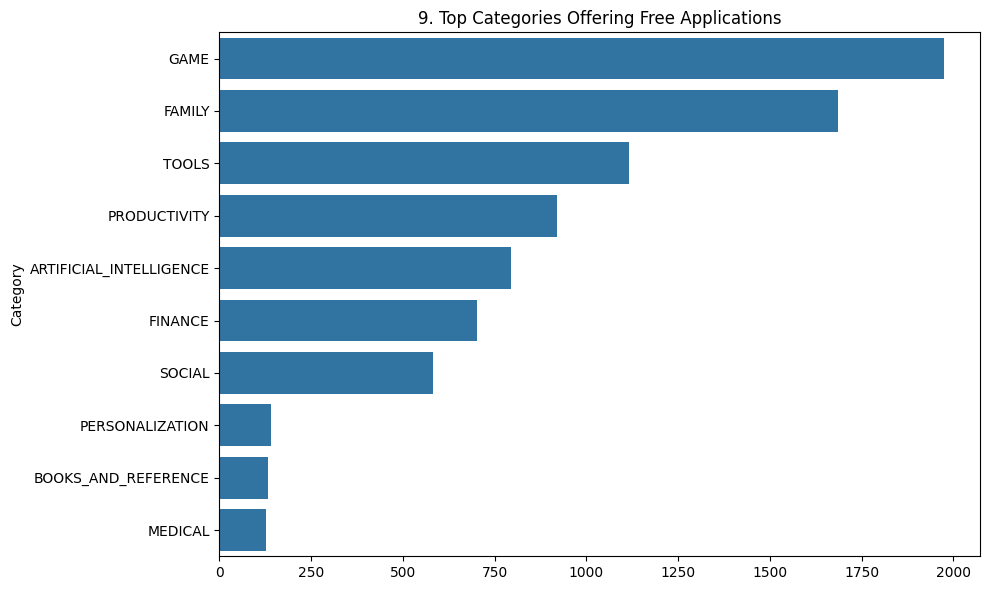

In [22]:
fig = plt.figure(figsize=(10,6))
free_category = df[df['Type']=='Free'].groupby('Category').size().sort_values(ascending=False).head(10)
sns.barplot(x=free_category.values, y=free_category.index)
plt.title(f'{plot_no}. Top Categories Offering Free Applications')
show_fig()
plot_no += 1

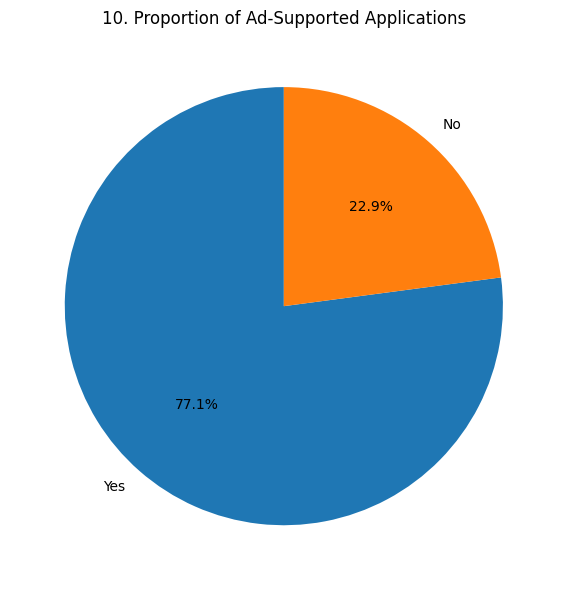

In [23]:
fig = plt.figure(figsize=(10,6))
ad_support = df['Ad Supported'].value_counts()
plt.pie(ad_support.values, labels=ad_support.index, autopct='%1.1f%%', startangle=90)
plt.title(f'{plot_no}. Proportion of Ad-Supported Applications')
show_fig()
plot_no += 1

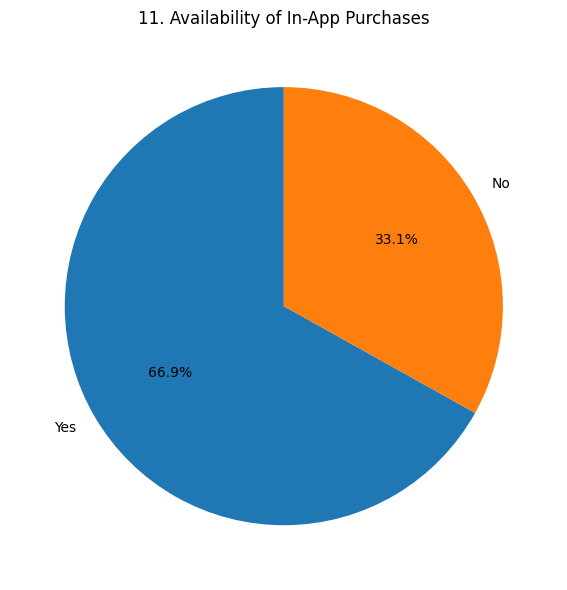

In [24]:
fig = plt.figure(figsize=(10,6))
iap = df['In-App Purchases'].value_counts()
plt.pie(iap.values, labels=iap.index, autopct='%1.1f%%', startangle=90)
plt.title(f'{plot_no}. Availability of In-App Purchases')
show_fig()
plot_no += 1

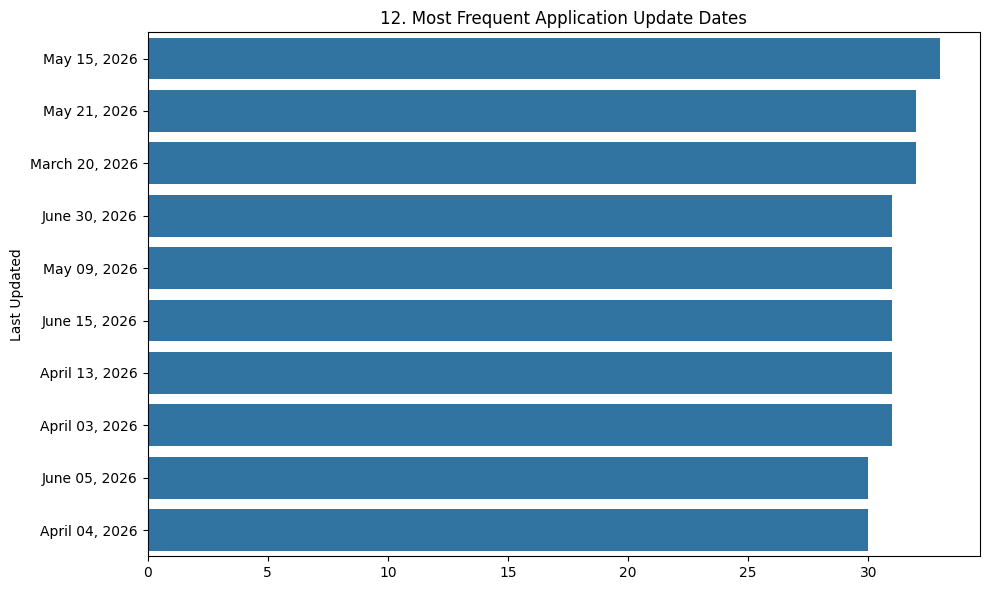

In [25]:
fig = plt.figure(figsize=(10,6))
top_updated = df['Last Updated'].value_counts().head(10)
sns.barplot(x=top_updated.values, y=top_updated.index)
plt.title(f'{plot_no}. Most Frequent Application Update Dates')
show_fig()
plot_no += 1

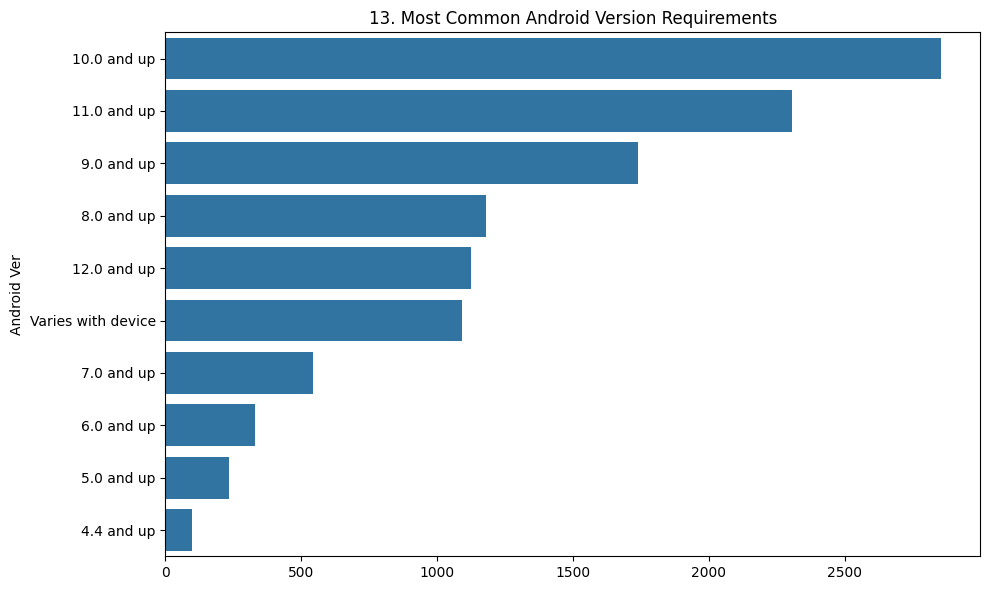

In [26]:
fig = plt.figure(figsize=(10,6))
android_versions = df['Android Ver'].value_counts().head(10)
sns.barplot(x=android_versions.values, y=android_versions.index)
plt.title(f'{plot_no}. Most Common Android Version Requirements')
show_fig()
plot_no += 1

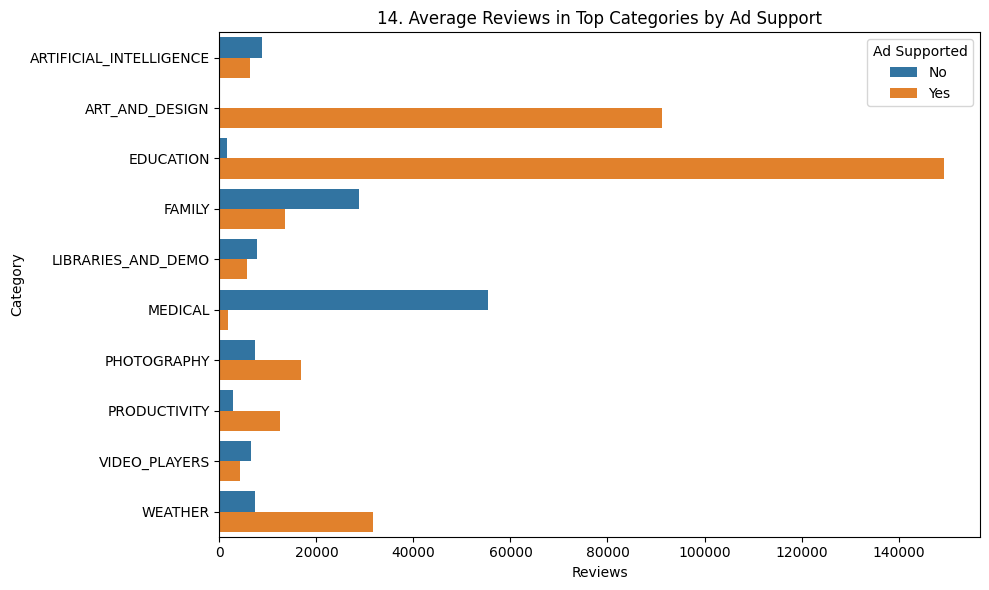

In [27]:
fig = plt.figure(figsize=(10,6))
reviews_by_ads = df.groupby(['Category','Ad Supported'])['Reviews'].mean().reset_index()
top_cat = reviews_by_ads.groupby('Category')['Reviews'].mean().sort_values(ascending=False).head(10).index
sns.barplot(data=reviews_by_ads[reviews_by_ads['Category'].isin(top_cat)], x='Reviews', y='Category', hue='Ad Supported')
plt.title(f'{plot_no}. Average Reviews in Top Categories by Ad Support')
show_fig()
plot_no += 1

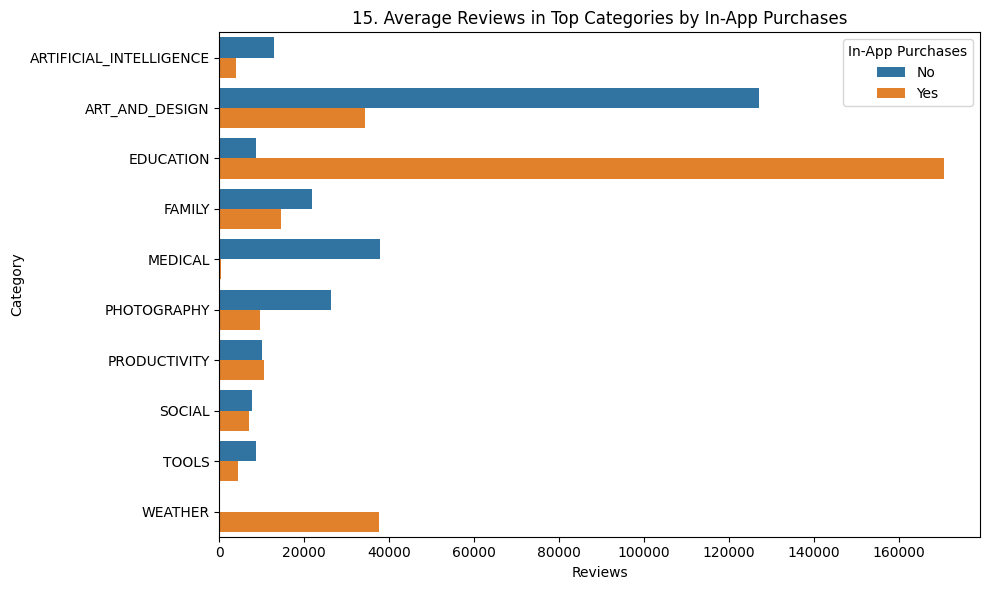

In [28]:
fig = plt.figure(figsize=(10,6))
reviews_by_iap = df.groupby(['Category','In-App Purchases'])['Reviews'].mean().reset_index()
top_cat = reviews_by_iap.groupby('Category')['Reviews'].mean().sort_values(ascending=False).head(10).index
sns.barplot(data=reviews_by_iap[reviews_by_iap['Category'].isin(top_cat)], x='Reviews', y='Category', hue='In-App Purchases')
plt.title(f'{plot_no}. Average Reviews in Top Categories by In-App Purchases')
show_fig()
plot_no += 1

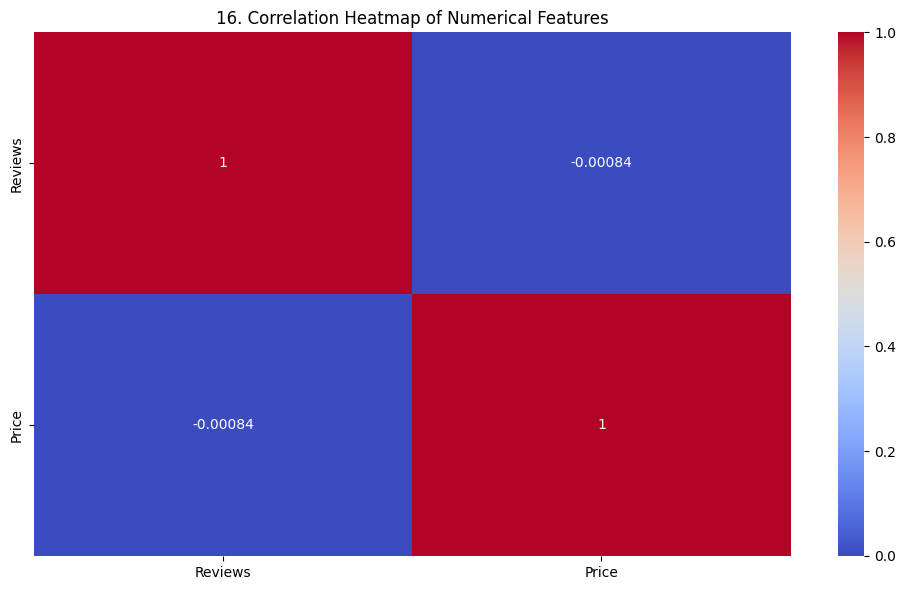

In [29]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create Copy

In [30]:
data = df.copy()

## Remove Unnecessary Columns

In [31]:
drop_cols = ["App", "Current Ver", "Last Updated"]
drop_cols = [c for c in drop_cols if c in data.columns]
data.drop(columns=drop_cols, inplace=True)

## Clean Installs

In [32]:
data["Installs"] = (
    data["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
data["Installs"] = pd.to_numeric(data["Installs"], errors="coerce")

## Clean Size

In [33]:
def convert_size(x):
    x = str(x)

    if "Varies" in x:
        return np.nan
    elif "M" in x:
        return float(x.replace("M", ""))
    elif "k" in x:
        return float(x.replace("k", "")) / 1024
    else:
        return np.nan

data["Size"] = data["Size"].apply(convert_size)

## Convert Yes No Columns

In [34]:
for col in ["In-App Purchases", "Ad Supported"]:
    if col in data.columns:
        data[col] = data[col].map({"Yes": 1, "No": 0})

## Select Target

In [35]:
target = "Category"

## Split Features And Target

In [36]:
X = data.drop(columns=[target])
y = data[target]

## Encode Target

In [37]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

## Identify Numeric And Categorical Features

In [38]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

## Create Numeric Pipeline

In [39]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Create Categorical Pipeline

In [40]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Create Preprocessor

In [41]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Split Dataset

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Create XGBoost Model

In [43]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1
    ))
])

## Train Model

In [44]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict Test Data

In [45]:
y_pred = model.predict(X_test)

## Print Accuracy

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy:.2%}")

Accuracy Score : 100.00%


## Plot Confusion Matrix

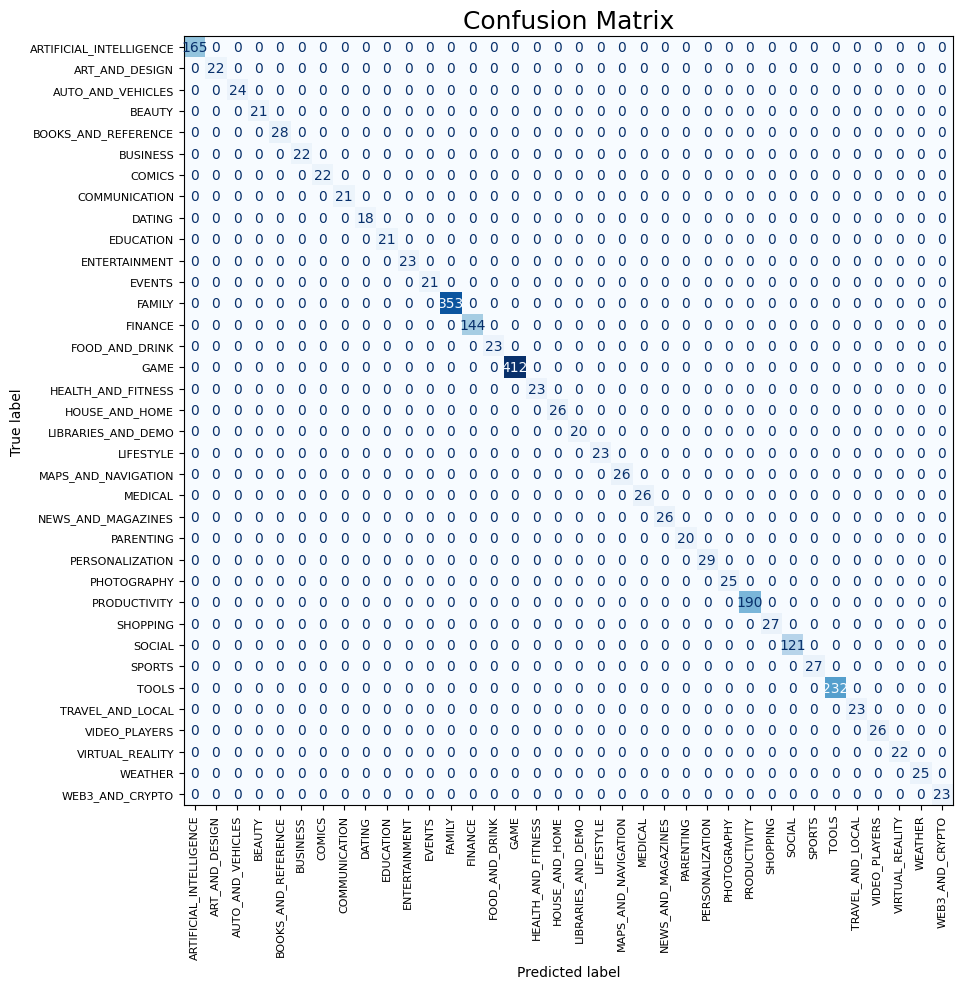

In [47]:
fig, ax = plt.subplots(figsize=(14, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    ax=ax,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=90
)

ax.set_title("Confusion Matrix", fontsize=18)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()